# **A2.1 Regresión logística y validación cruzada**

---

### **Introducción**

En esta actividad se buscará predecir el nivel de crimen que tendrá un estado utilizando sus indicadores de marginación utilizando los datos recabados de 2015 a 2023. Conocemos cuántos delitos hubo en cada estado cada año, y también sabemos indicadores de pobreza, analfabetismo, falta de servicios y desocupación en esos mismos estados.

Este reporte busca encontrar la respuesta del caso en el que la gente vive en pobreza, sin servicios básicos, sin educación, ¿es más probable que haya más delitos? Y si es así, ¿qué indicadores son los más importantes para saber esto?

Si se obtiene un resultado que se capaz de predecir qué estado tendrá alto crimen basándonos en datos socioeconómicos, esto podría ayudar a:
- Identificar estados de alto riesgo antes de que el problema sea grave
- Entender qué factores socioeconómicos están más conectados con la criminalidad
- Orientar políticas públicas hacia los problemas que realmente importan
- Verificar si la relación entre marginación y crimen que observamos en los datos también funciona para predecir

### **Carga de datos y contexto**

**Datos de crimen (SESNSP):**
- Registros de delitos mensuales en 32 estados mexicanos, de 2015 a 2023
- Incluye todo tipo de delitos: robos, asaltos, homicidios, fraudes, etc.
- Total: 84,097 registros que colapsamos a **tasa anual: delitos por 100,000 habitantes en cada estado cada año**

**Datos de marginación (CONAPO):**
- De dos años específicos: 2015 y 2020, con datos de los 32 estados
- Incluyen 10 indicadores que miden pobreza y desigualdad:
  - **ANALF**: Analfabetismo (% sin saber leer ni escribir)
  - **SBASC**: Sin servicios básicos (% sin agua, drenaje, electricidad)
  - **OVSDE, OVSEE, OVSAE**: Desocupación educativa y económica (% sin educación básica o sin trabajo)
  - **VHAC**: Vivienda precaria (% en casas hacinadas)
  - **OVPT**: Privación por otros servicios (% sin acceso a servicios)
  - **PL_5000**: Personas en pobreza extrema (con menos de $5,000 pesos/mes)
  - **IM**: Índice de Marginación (consolidado, entre 0 y 1)
  - **PO2SM**: Personas con menos de 2 salarios mínimos

Para obtener un conjunto de datos que cuente con todas las variables relevantes que se buscan utilizar en el modelo de clasificación fusionamos los conjuntos de datos de crimen y marginación en cada estado para cada año (2015-2023), Además para los años 2016-2019 y 2021-2023 donde no teníamos datos de marginación realizamos una interpolación de los datos. Obteniendo como resultado 288 combinaciones de estado-año listos para análisis.

Utilizando estos datos:
- Calcularemos la *mediana* de tasa de crimen (punto medio: 1,458 delitos/100k)
- Se clasificaron los estados arriba de la mediana = **ALTO crimen** y abajo de la mediana = **BAJO crimen**
- se generará un modelo para predecir esta clasificación usando los 10 indicadores de marginación como señales

In [1]:
# Carga de datos - Proyecto de Crimen y Marginacion
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, 
    f1_score, roc_curve, auc, roc_auc_score, classification_report
)
import warnings
import unicodedata
warnings.filterwarnings('ignore')

# Configurar estilo de visualizacion
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# FUNCIONES DE SOPORTE
def limpiar_texto(texto):
    # Estandariza nombres de entidades (elimina acentos)
    if not isinstance(texto, str): 
        return texto
    texto = unicodedata.normalize('NFD', texto)
    return texto.encode('ascii', 'ignore').decode("utf-8").upper().strip()

# CARGA Y PREPARACION DE DATOS DE CRIMEN
print("Cargando data de incidencia delictiva...")
df_crimen = pd.read_csv('crimen_nac.csv', encoding='latin-1')

# Sumatoria mensual: Crear 'Total_Delitos_Anual'
meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 
         'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
df_crimen[meses] = df_crimen[meses].fillna(0)
df_crimen['Total_Delitos_Anual'] = df_crimen[meses].sum(axis=1)

# Colapsamiento estructural por estado y ano
df_crimen_colapsado = df_crimen.groupby(['Entidad', 'Año'])['Total_Delitos_Anual'].sum().reset_index()
df_crimen_colapsado['Entidad'] = df_crimen_colapsado['Entidad'].apply(limpiar_texto)

print(f"Datos de crimen: {len(df_crimen_colapsado)} registros agregados por estado-ano")

# CARGA Y PREPARACION DE DATOS DE MARGINACION
print("\nCargando datos de marginacion (CONAPO 2015 y 2020)...")
df_m15 = pd.read_csv('ime_dp2_2015.csv')
df_m20 = pd.read_csv('data-2026-02-16.csv')

def procesar_marginacion(df, anio):
    # Procesa dataset de marginacion y selecciona variables clave
    df.columns = df.columns.str.upper()
    
    # Renombrar columnas si es necesario
    if 'IM' not in df.columns:
        col_im = [c for c in df.columns if 'IM' in c or 'INDICE' in c]
        if col_im: 
            df = df.rename(columns={col_im[0]: 'IM'})
    if 'NOM_ENT' not in df.columns:
        col_ent = [c for c in df.columns if 'ENT' in c or 'ESTADO' in c]
        if col_ent: 
            df = df.rename(columns={col_ent[0]: 'NOM_ENT'})
    
    # Seleccionar variables de interes
    cols_interes = ['NOM_ENT', 'POB_TOT', 'IM', 'ANALF', 'SBASC', 'OVSDE', 
                    'OVSEE', 'OVSAE', 'OVPT', 'VHAC', 'PL_5000', 'PO2SM']
    df_filtrado = df[[c for c in cols_interes if c in df.columns]].copy()
    df_filtrado['Año'] = anio
    return df_filtrado

df_m15_limpio = procesar_marginacion(df_m15, 2015)
df_m20_limpio = procesar_marginacion(df_m20, 2020)
df_marginacion = pd.concat([df_m15_limpio, df_m20_limpio], ignore_index=True)
df_marginacion['NOM_ENT'] = df_marginacion['NOM_ENT'].apply(limpiar_texto)

print(f"Datos de marginacion: {len(df_marginacion)} registros (2015 y 2020)")

# INTERPOLACION Y PROYECCION (COMPLETAR ANOS FALTANTES)
print("\nRealizando interpolacion para anos faltantes (2016-2019, 2021-2023)...")
estados = sorted(df_marginacion['NOM_ENT'].unique())
anios_totales = np.arange(2015, 2024)
esqueleto = pd.MultiIndex.from_product([estados, anios_totales], names=['NOM_ENT', 'Año']).to_frame(index=False)

df_proyeccion = pd.merge(esqueleto, df_marginacion, on=['NOM_ENT', 'Año'], how='left')
df_proyeccion = df_proyeccion.sort_values(['NOM_ENT', 'Año'])

lista_estados = []
for estado in estados:
    df_estado = df_proyeccion[df_proyeccion['NOM_ENT'] == estado].copy()
    cols_numericas = df_estado.select_dtypes(include=[np.number]).columns.difference(['Año'])
    df_estado[cols_numericas] = df_estado[cols_numericas].interpolate(
        method='linear', limit_direction='both'
    )
    lista_estados.append(df_estado)

df_marginacion_completa = pd.concat(lista_estados, ignore_index=True)
print(f"Interpolacion completada: {len(df_marginacion_completa)} registros (2015-2023)")

# INTEGRACION FINAL Y CREACION DE TASA DELICTIVA
print("\nIntegrando datos y calculando tasa delictiva...")
df_final = pd.merge(
    df_crimen_colapsado, 
    df_marginacion_completa, 
    left_on=['Entidad', 'Año'], 
    right_on=['NOM_ENT', 'Año'],
    how='inner'
)

df_final = df_final.drop(columns=['NOM_ENT'])
df_final['Tasa_Delictiva'] = (df_final['Total_Delitos_Anual'] / df_final['POB_TOT']) * 100000
df_final = df_final.drop(columns=['Total_Delitos_Anual'])
df_final = df_final.sort_values(by=['Año', 'Entidad'])

print("\nDataset maestro generado con exito")
print(f"Dimensiones: {df_final.shape[0]} filas x {df_final.shape[1]} columnas")
print(f"Periodo: {df_final['Año'].min()}-{df_final['Año'].max()}")
print(f"Estados: {df_final['Entidad'].nunique()}")
print(f"\nPrimeras filas del dataset:")
display(df_final.head(10))
print(f"\nEstadisticas descriptivas:")
display(df_final.describe())

Cargando data de incidencia delictiva...
Datos de crimen: 288 registros agregados por estado-ano

Cargando datos de marginacion (CONAPO 2015 y 2020)...
Datos de marginacion: 64 registros (2015 y 2020)

Realizando interpolacion para anos faltantes (2016-2019, 2021-2023)...
Interpolacion completada: 306 registros (2015-2023)

Integrando datos y calculando tasa delictiva...

Dataset maestro generado con exito
Dimensiones: 288 filas x 14 columnas
Periodo: 2015-2023
Estados: 32

Primeras filas del dataset:


,Entidad,Año,POB_TOT,IM,ANALF,SBASC,OVSDE,OVSEE,OVSAE,OVPT,VHAC,PL_5000,PO2SM,Tasa_Delictiva
0,AGUASCALIENTES,2015,1312544.0,17.883964,2.601353,29.721797,0.681147,0.304155,0.813920,0.752952,21.862232,25.162585,34.604084,1770.454933
9,BAJA CALIFORNIA,2015,3315766.0,18.464138,1.961601,30.077841,0.268934,0.472493,2.817705,1.148904,23.032223,10.349162,22.845516,3653.032210
18,BAJA CALIFORNIA SUR,2015,712029.0,17.320595,2.505451,29.439127,0.386485,1.136240,7.146918,4.083650,26.230970,15.618886,22.365039,3015.326623
27,CAMPECHE,2015,899931.0,13.684555,6.681547,35.743791,4.085619,1.589287,6.489314,2.949209,37.931783,30.875478,40.693940,221.572543
36,CHIAPAS,2015,5217908.0,8.449801,14.984097,53.400565,2.941142,2.485504,13.445785,11.775397,44.460574,57.856520,62.463392,419.190986
45,CHIHUAHUA,2015,3556574.0,16.821709,2.667242,33.308660,1.381523,1.805718,2.388772,1.758809,22.159112,17.049919,34.769863,1786.578882
54,CIUDAD DE MEXICO,2015,9209944.0,23.143109,1.429621,17.641964,0.051952,0.051820,1.241104,0.633649,14.397804,1.007987,56.132168,1846.905910
63,COAHUILA DE ZARAGOZA,2015,2954915.0,18.400944,1.987870,28.055475,0.620634,0.290767,1.665703,0.657853,23.617926,12.148640,27.944015,1597.034094
72,COLIMA,2015,711235.0,17.432451,3.901349,33.794871,0.390444,0.383610,0.957736,2.446892,25.652881,14.474963,31.177934,928.103932
81,DURANGO,2015,1754754.0,14.942236,3.174132,34.460745,3.697342,2.628997,3.257774,4.327911,24.583760,36.188491,39.160855,1685.193480



Estadisticas descriptivas:


,Año,POB_TOT,IM,ANALF,SBASC,OVSDE,OVSEE,OVSAE,OVPT,VHAC,PL_5000,PO2SM,Tasa_Delictiva
count,288.000000,2.880000e+02,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000
mean,2019.000000,3.866561e+06,17.857534,4.973352,31.691383,1.978084,0.873265,4.021914,3.749695,23.043002,29.197001,57.133743,1511.028807
std,2.586483,3.197568e+06,3.303586,3.265801,7.732709,2.172880,0.675547,3.483437,3.566110,6.881851,16.184372,14.955664,840.120233
min,2015.000000,7.112350e+05,6.928344,1.429621,17.641964,0.051952,0.051820,0.552683,0.633649,13.132191,1.007987,16.147650,90.697652
25%,2017.000000,1.813176e+06,16.311494,2.643087,26.991249,0.567858,0.381912,1.403170,1.557448,17.505891,14.385886,46.791801,830.615409
50%,2019.000000,2.997990e+06,18.229581,3.899466,30.063351,1.411048,0.639300,2.820633,2.435722,22.235327,30.046267,58.504352,1457.950489
75%,2021.000000,4.841510e+06,20.083050,6.301040,34.826597,2.469859,1.160223,5.393310,4.303201,26.642784,39.074320,69.255061,2061.626970
max,2023.000000,1.699242e+07,23.444318,14.984097,53.400565,13.216815,2.874475,15.641990,15.266973,44.460574,61.508475,85.570274,3943.171300


### **Estrategia de análisis**

1. **Cargar los datos**: Integramos registros de 84,097 delitos con los 10 indicadores de marginación de los 32 estados mexicanos, generando 288 observaciones completas (2015-2023).

2. **Crear una predicción simple**: En lugar de predecir el número exacto de delitos (que es difícil), dividiremos los estados en dos grupos:
   - **Grupo ALTO**: Estados con más delitos que la mediana (más de 1,458 delitos/100k)
   - **Grupo BAJO**: Estados con menos delitos que la mediana
   
3. **Dividir datos en entrenamiento y prueba**: 
   - **70% para entrenar** el modelo (201 observaciones): aquí el modelo aprende qué indicadores predicen alto vs bajo crimen
   - **30% para probar** (87 observaciones): aquí verificamos si el modelo funciona en datos que nunca vio

4. **Entrenar un modelo de predicción**: Usaremos todos los 10 indicadores de marginación para predecir si un estado-año tendrá alto o bajo crimen. El modelo no es complicado: busca patrones donde ciertos indicadores tienden a asociarse con alto crimen.

5. **Verificar si funciona**: Haremos 5 pruebas independientes (validación cruzada) para asegurarnos de que el modelo no es un accidente. También probaremos cuál es el nivel de confianza correcto para hacer la predicción con el fin de responder la pregunta, ¿a partir de qué probabilidad decimos "sí, es alto crimen"?

### **Definición del problema de clasificación**


En lugar de intentar predecir el número exacto de delitos, vamos a predecir si un estado está en la mitad "más peligrosa" o en la mitad "menos peligrosa".
Esto es útil porque:
- Es más fácil acertar si algo es "alto" o "bajo" que predecir el número exacto
- Refleja mejor las decisiones de política pública (¿necesita intervención o no?)
- Si el modelo se equivoca, los errores son menos costosos

Para dividir los datos usaremos el punto medio exacto (mediana) de la tasa de crimen: 1,458 delitos por 100,000 habitantes

- **ALTO crimen**: Estados-año con más de 1,458 delitos/100k (144 casos en nuestro dataset = 50%)
- **BAJO crimen**: Estados-año con menos de 1,458 delitos/100k (144 casos en nuestro dataset = 50%)

Esto crea un balance perfecto: 50-50, ningún grupo está favorecido sobre el otro.

Para predecir el modelo utilizara los 10 indicadores de marginación/pobreza que ya tenemos. El modelo dirá: "Viendo estos indicadores socioeconómicos, este estado-año probablemente está en el grupo ALTO" o "probablemente está en el grupo BAJO".

Variable de clasificacion creada exitosamente.
Mediana de Tasa Delictiva: 1457.95 delitos por 100,000 habitantes
Distribucion de la variable 'Incidencia' en el dataset original:
Incidencia_Categoria
Alta    144
Baja    144
Name: count, dtype: int64
Proporcion de clases:
Incidencia_Categoria
Alta    50.0
Baja    50.0
Name: proportion, dtype: float64


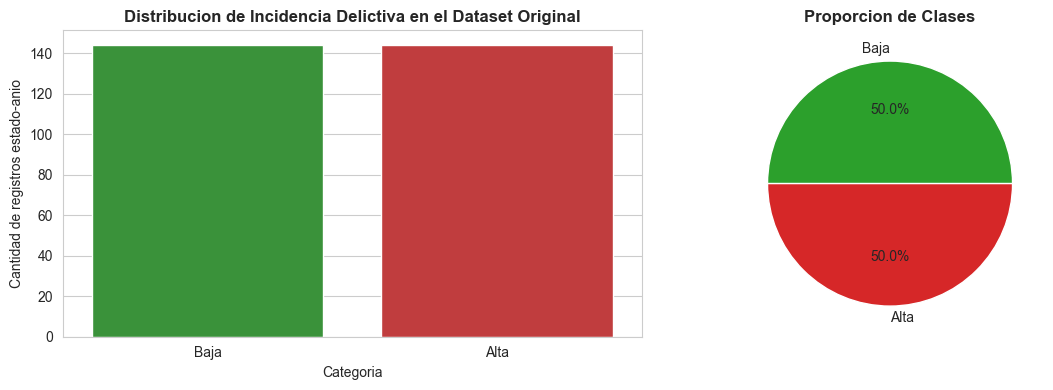

ANALISIS DEL BALANCE DE CLASES
Proporcion de Alta Incidencia: 50.00%
Proporcion de Baja Incidencia: 50.00%
El dataset presenta un balance muy adecuado de clases (cercano al 50-50).


In [3]:
# Crear variable binaria de clasificacion basada en la mediana de tasa delictiva
mediana_tasa = df_final['Tasa_Delictiva'].median()

# 1 = Alta Incidencia (arriba de la mediana), 0 = Baja Incidencia (abajo de la mediana)
df_final['Incidencia'] = (df_final['Tasa_Delictiva'] >= mediana_tasa).astype(int)

# Mapear etiquetas para mayor claridad
incidencia_labels = {0: 'Baja', 1: 'Alta'}
df_final['Incidencia_Categoria'] = df_final['Incidencia'].map(incidencia_labels)

print("Variable de clasificacion creada exitosamente.")
print(f"Mediana de Tasa Delictiva: {mediana_tasa:.2f} delitos por 100,000 habitantes")
print("Distribucion de la variable 'Incidencia' en el dataset original:")
print(df_final['Incidencia_Categoria'].value_counts())
print("Proporcion de clases:")
print(df_final['Incidencia_Categoria'].value_counts(normalize=True).mul(100).round(2))

# Visualizacion de la distribucion
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Grafico de barras
sns.countplot(data=df_final, x='Incidencia_Categoria', ax=axes[0], palette=['#2ca02c', '#d62728'])
axes[0].set_title('Distribucion de Incidencia Delictiva en el Dataset Original', fontweight='bold')
axes[0].set_ylabel('Cantidad de registros estado-anio')
axes[0].set_xlabel('Categoria')
axes[0].set_xticklabels(['Baja', 'Alta'])

# Grafico de pastel
df_final['Incidencia_Categoria'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                                         colors=['#2ca02c', '#d62728'], labels=['Baja', 'Alta'])
axes[1].set_title('Proporcion de Clases', fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print("="*60)
print("ANALISIS DEL BALANCE DE CLASES")
print("="*60)
ratio = df_final['Incidencia'].sum() / len(df_final)
print(f"Proporcion de Alta Incidencia: {ratio:.2%}")
print(f"Proporcion de Baja Incidencia: {1-ratio:.2%}")

if 0.4 <= ratio <= 0.6:
    print("El dataset presenta un balance muy adecuado de clases (cercano al 50-50).")
else:
    diff = abs(ratio - 0.5)
    print(f"El dataset presenta una distribucion de clases con diferencia de {diff:.1%}.")

### **Separación de datos y análisis del balance de clases**

Como se mencionó anteriormente se dividen los datos en entrenamiento y prueba con la finalidad de conocer si el modelo funciona:

- **70% para entrenar** (201 datos): El modelo aprende patrones de estos datos - qué marginación predice alto crimen
- **30% para probar** (87 datos): Le decimos "Aquí hay nuevos estados-año que nunca viste. ¿Qué predices?" Si mantiene buen rendimiento, es un modelo real

Utilizamos el estratificado debido a que nuestro conjunto de datos tiene 50% de ALTO y 50% de BAJO. Si la división fuera completamente aleatoria, podríamos terminar con:
- Training: 70% ALTO, 30% BAJO (desequilibrado)
- Test: 30% ALTO, 70% BAJO (desequilibrado)

Esto haría que el modelo no aprendiera bien. Por eso que la estratificación garantiza que:

- **Training set** (201 datos): ~100 BAJO, ~101 ALTO (balance 50-50 preservado)
- **Test set** (87 datos): ~44 BAJO, ~43 ALTO (balance 50-50 preservado)

De esta forma, ambos conjuntos reflejan la realidad: mitad de casos tienen alto crimen, mitad bajo crimen.

Variables predictoras disponibles: ['IM', 'ANALF', 'SBASC', 'OVSDE', 'OVSEE', 'OVSAE', 'OVPT', 'VHAC', 'PL_5000', 'PO2SM']
Total de caracteristicas: 10

Division de datos completada.
Tamanio del conjunto de entrenamiento: 201 muestras (69.8%)
Tamanio del conjunto de prueba: 87 muestras (30.2%)

BALANCE DE CLASES EN CADA CONJUNTO




,Dataset Original,Entrenamiento,Prueba
Baja Incidencia,50.0,49.75,50.57
Alta Incidencia,50.0,50.25,49.43


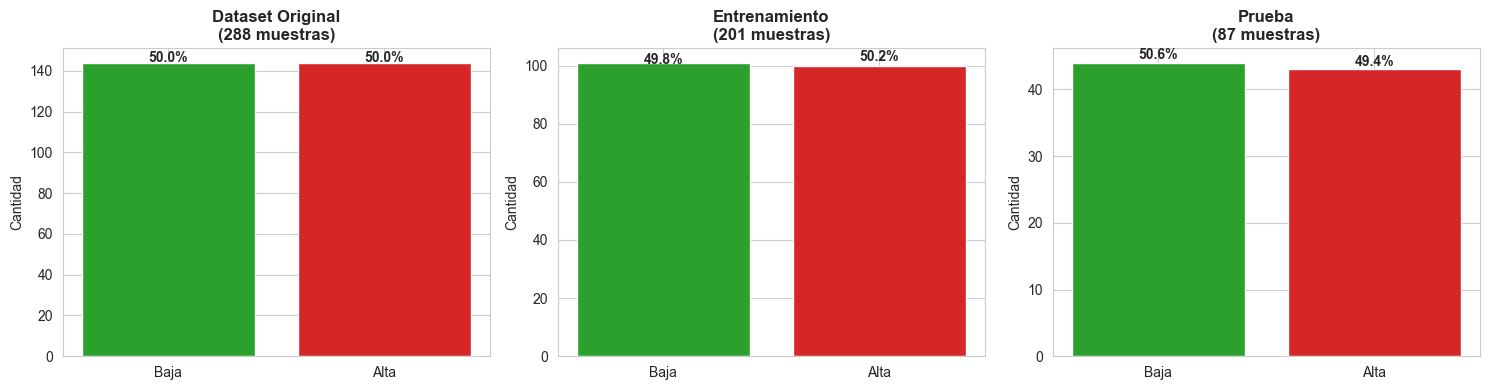


La estratificacion ha preservado adecuadamente el balance de clases en todos los conjuntos.


In [4]:
# Preparar variables independientes y dependiente
# Seleccionar caracteristicas (excluir Tasa_Delictiva y variables derivadas)
features_to_use = ['IM', 'ANALF', 'SBASC', 'OVSDE', 'OVSEE', 'OVSAE', 'OVPT', 'VHAC', 'PL_5000', 'PO2SM']

# Crear matriz de caracteristicas
X = df_final[features_to_use].copy()
y = df_final['Incidencia'].copy()

# Verificar variables disponibles
variables_disponibles = [f for f in features_to_use if f in df_final.columns]
print(f"Variables predictoras disponibles: {variables_disponibles}")
print(f"Total de caracteristicas: {len(variables_disponibles)}")

X = df_final[variables_disponibles]

# Division estratificada 70-30 (entrenamiento-prueba)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("\nDivision de datos completada.")
print(f"Tamanio del conjunto de entrenamiento: {X_train.shape[0]} muestras ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Tamanio del conjunto de prueba: {X_test.shape[0]} muestras ({X_test.shape[0]/len(X)*100:.1f}%)")

# Analisis de balance de clases
print("\n" + "="*60)
print("BALANCE DE CLASES EN CADA CONJUNTO")
print("="*60)

# Preparar datos para las comparaciones
balance_data = {
    'Dataset Original': y.value_counts(normalize=True).mul(100),
    'Entrenamiento': y_train.value_counts(normalize=True).mul(100),
    'Prueba': y_test.value_counts(normalize=True).mul(100)
}

# Crear tabla de balance
balance_table = pd.DataFrame(balance_data).round(2)
balance_table.index = ['Baja Incidencia', 'Alta Incidencia']

print("\n")
display(balance_table)

# Visualizacion del balance
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
datasets = [
    (y, 'Dataset Original'),
    (y_train, 'Entrenamiento'),
    (y_test, 'Prueba')
]

for idx, (y_data, title) in enumerate(datasets):
    counts = y_data.value_counts()
    axes[idx].bar(['Baja', 'Alta'], counts.values, color=['#2ca02c', '#d62728'])
    axes[idx].set_title(f'{title}\n({len(y_data)} muestras)', fontweight='bold')
    axes[idx].set_ylabel('Cantidad')
    
    # Aniadir porcentajes
    for i in range(2):
        if i in counts.index:
            count = counts[i]
            percentage = count / len(y_data) * 100
            axes[idx].text(i, count + 0.5, f'{percentage:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nLa estratificacion ha preservado adecuadamente el balance de clases en todos los conjuntos.")

### **Escalamiento de características**

La regresión logística es sensible a la escala de las variables. Para garantizar que variables con diferentes rangos de valores no dominen el aprendizaje del modelo, se realiza un escalamiento de características utilizando estandarización (media 0, desviación estándar 1).

**Importante:** El escalador se ajusta únicamente con los datos de entrenamiento y se aplica a los conjuntos de prueba y validación cruzada, simulando una situación de predicción real.

In [5]:
# Escalamiento de caracteristicas
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir a DataFrames para facilitar la interpretacion posterior
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Caracteristicas escaladas correctamente.")
print(f"Media de X_train_scaled:")
print(X_train_scaled.mean().round(6))
print(f"Desviacion estandar de X_train_scaled:")
print(X_train_scaled.std().round(2))

Caracteristicas escaladas correctamente.
Media de X_train_scaled:
IM        -0.0
ANALF     -0.0
SBASC     -0.0
OVSDE     -0.0
OVSEE      0.0
OVSAE      0.0
OVPT      -0.0
VHAC      -0.0
PL_5000   -0.0
PO2SM     -0.0
dtype: float64
Desviacion estandar de X_train_scaled:
IM         1.0
ANALF      1.0
SBASC      1.0
OVSDE      1.0
OVSEE      1.0
OVSAE      1.0
OVPT       1.0
VHAC       1.0
PL_5000    1.0
PO2SM      1.0
dtype: float64


### **Validación cruzada: Verificar que el modelo NO es un accidente**

Tenemos 288 observaciones: 32 estados × 9 años (2015-2023) de crimen y marginación. Si entrenamos con todos los datos de cada estado MENOS un grupo, y luego probamos con ese grupo, el modelo podría haber "memorizado" ese patrón específico de Veracruz. Necesitamos saber si funciona con cualquier estado en cualquier año.

Dividimos los 201 datos de entrenamiento en 5 grupos:

- **Grupo 1**: ~40 observaciones (algunos estados en algunos años)
- **Grupo 2**: ~40 observaciones (otros estados/años)
- **Grupo 3, 4, 5**: Similar

Luego hacemos 5 entrenamientos:

1. **Intento 1**: Entrenamos con Grupos 2,3,4,5 (=160 datos) → Probamos con Grupo 1 (40 datos)
2. **Intento 2**: Entrenamos con Grupos 1,3,4,5 (=160 datos) → Probamos con Grupo 2 (40 datos)
3. **Intento 3**: Entrenamos con Grupos 1,2,4,5 (=160 datos) → Probamos con Grupo 3 (40 datos)
4. **Intento 4**: Entrenamos con Grupos 1,2,3,5 (=160 datos) → Probamos con Grupo 4 (40 datos)
5. **Intento 5**: Entrenamos con Grupos 1,2,3,4 (=160 datos) → Probamos con Grupo 5 (40 datos)

En cada grupo de 40 datos, mantenemos el balance 50-50 (20 ALTO, 20 BAJO crimen). De esta forma, cada intento es una prueba independiente en datos diferentes.

Como resultado final promediamos los 5 intentos. Si todos dan resultados similares (por ejemplo, todos detectan 80% de casos de alto crimen), confiamos en que el modelo funciona para cualquier estado-año en México, no sólo para los que vio durante entrenamiento.

Después, probamos una última vez con los 87 datos de prueba que guardamos desde el inicio.

RESULTADOS DE VALIDACIÓN CRUZADA (5 Pliegues)


,Pliegue,Exactitud,Precisión,Sensibilidad,F1-Score,AUC
0,1,0.6829,0.7000,0.6667,0.6829,0.7786
1,2,0.7500,0.7083,0.8500,0.7727,0.7750
2,3,0.7000,0.6818,0.7500,0.7143,0.7800
3,4,0.6750,0.6522,0.7500,0.6977,0.8362
4,5,0.6750,0.6296,0.8500,0.7234,0.7138



RESUMEN DE VALIDACIÓN CRUZADA


,Métrica,Media,Desv. Est.
0,Exactitud,0.6966,0.0282
1,Precisión,0.6744,0.0295
2,Sensibilidad,0.7733,0.0696
3,F1-Score,0.7182,0.0306
4,AUC,0.7767,0.0388


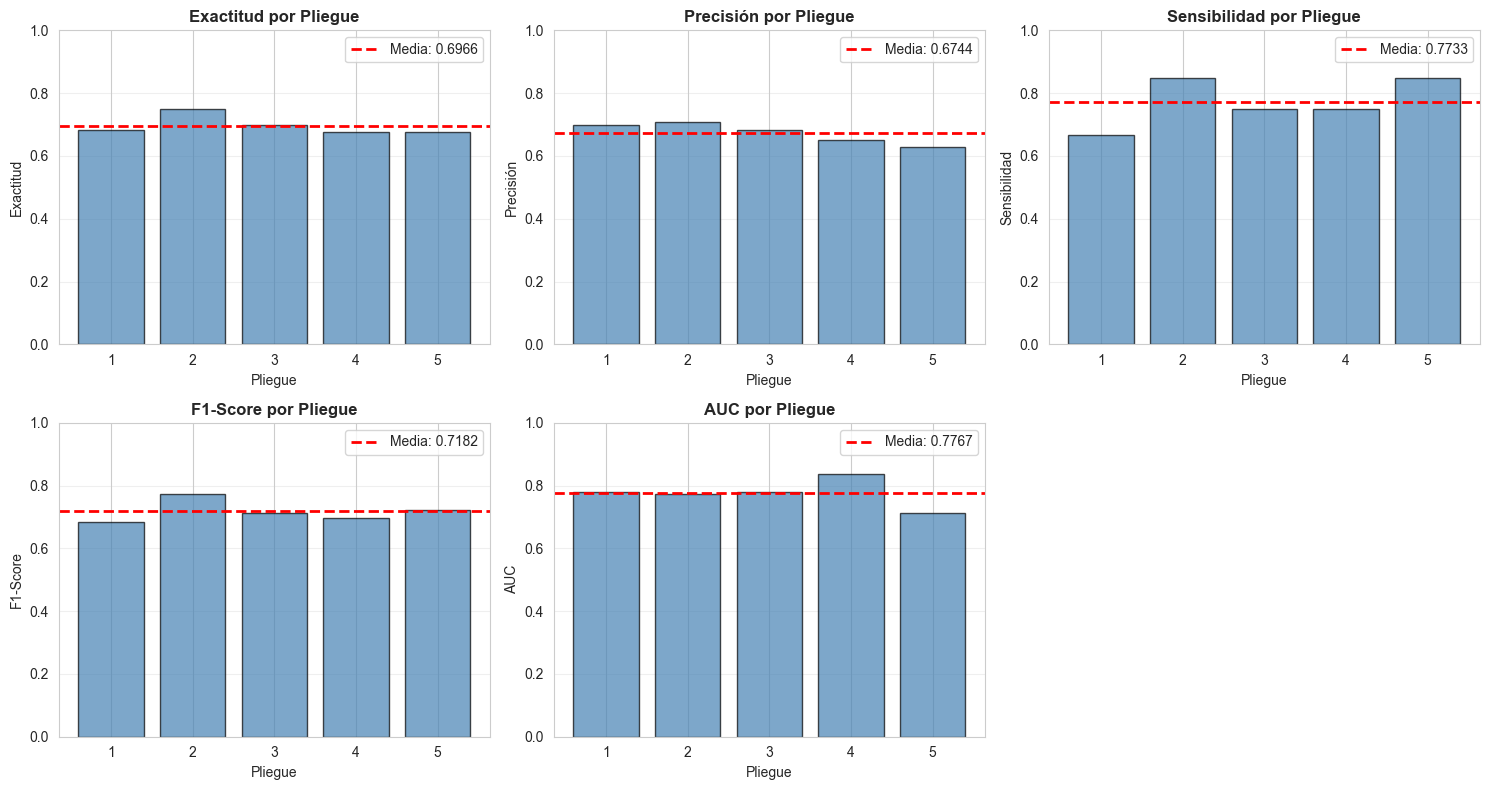


✓ La validación cruzada proporciona una estimación robusta del desempeño del modelo.
  La variabilidad entre pliegues (desv. est.) es relativamente baja, indicando estabilidad.


In [6]:
# Configurar validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Definir modelo de regresión logística
log_reg = LogisticRegression(random_state=42, max_iter=1000)

# Métricas a calcular en validación cruzada
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

# Realizar validación cruzada
cv_results = cross_validate(log_reg, X_train_scaled, y_train, cv=cv, scoring=scoring, return_train_score=True)

print("RESULTADOS DE VALIDACIÓN CRUZADA (5 Pliegues)")
print("="*60)

# Crear tabla de resultados
cv_metrics = pd.DataFrame({
    'Pliegue': range(1, 6),
    'Exactitud': cv_results['test_accuracy'].round(4),
    'Precisión': cv_results['test_precision'].round(4),
    'Sensibilidad': cv_results['test_recall'].round(4),
    'F1-Score': cv_results['test_f1'].round(4),
    'AUC': cv_results['test_roc_auc'].round(4)
})

display(cv_metrics)

# Estadísticas de resumen
print("\nRESUMEN DE VALIDACIÓN CRUZADA")
print("="*60)

cv_summary = pd.DataFrame({
    'Métrica': ['Exactitud', 'Precisión', 'Sensibilidad', 'F1-Score', 'AUC'],
    'Media': [
        f"{cv_results['test_accuracy'].mean():.4f}",
        f"{cv_results['test_precision'].mean():.4f}",
        f"{cv_results['test_recall'].mean():.4f}",
        f"{cv_results['test_f1'].mean():.4f}",
        f"{cv_results['test_roc_auc'].mean():.4f}"
    ],
    'Desv. Est.': [
        f"{cv_results['test_accuracy'].std():.4f}",
        f"{cv_results['test_precision'].std():.4f}",
        f"{cv_results['test_recall'].std():.4f}",
        f"{cv_results['test_f1'].std():.4f}",
        f"{cv_results['test_roc_auc'].std():.4f}"
    ]
})

display(cv_summary)

# Visualización de la variabilidad de métricas
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
metric_labels = ['Exactitud', 'Precisión', 'Sensibilidad', 'F1-Score', 'AUC']

for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
    ax = axes[idx // 3, idx % 3]
    values = cv_results[f'test_{metric}']
    ax.bar(range(1, 6), values, color='steelblue', alpha=0.7, edgecolor='black')
    ax.axhline(values.mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {values.mean():.4f}')
    ax.set_title(f'{label} por Pliegue', fontweight='bold')
    ax.set_xlabel('Pliegue')
    ax.set_ylabel(label)
    ax.set_ylim([0, 1])
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

# Eliminar subplot vacío
axes[1, 2].remove()

plt.tight_layout()
plt.show()

print("\n✓ La validación cruzada proporciona una estimación robusta del desempeño del modelo.")
print(f"  La variabilidad entre pliegues (desv. est.) es relativamente baja, indicando estabilidad.")

### **Entrenamiento final y evaluación en el conjunto de prueba**

Una vez se ha estimado el desempeño del modelo mediante validación cruzada, se entrena un modelo final utilizando la totalidad del conjunto de entrenamiento. Este modelo se evalúa posteriormente en el conjunto de prueba independiente, que no fue utilizado en ninguna etapa anterior.

**Matriz de confusión:** Presenta una tabla que cruza los valores predichos con los valores reales, permitiendo identificar:
- Verdaderos Positivos (VP): Estudiantes aprobados predichos correctamente
- Verdaderos Negativos (VN): Estudiantes reprobados predichos correctamente
- Falsos Positivos (FP): Estudiantes reprobados predichos como aprobados
- Falsos Negativos (FN): Estudiantes aprobados predichos como reprobados

MATRIZ DE CONFUSIÓN (Conjunto de Prueba)


                  Predicho Reprobado  Predicho Aprobado
Real Reprobado            30                   14
Real Aprobado             3                   40

MÉTRICAS DE EVALUACIÓN (Conjunto de Prueba)


,Métrica,Valor,Interpretación
0,Exactitud (Accuracy),0.8046,80.5% de predicciones correctas
1,Precisión,0.7407,74.1% de aprobados predichos son correctos
2,Sensibilidad (Recall),0.9302,93.0% de aprobados reales se detectan
3,Especificidad,0.6818,68.2% de reprobados reales se detectan
4,F1-Score,0.8247,Promedio ponderado de precisión y sensibilidad


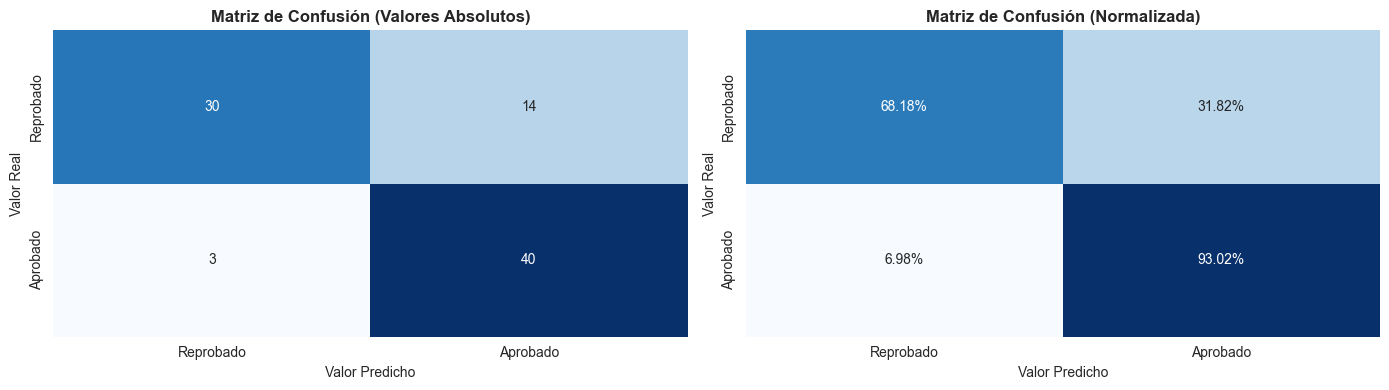

In [7]:
# Entrenar modelo final con el conjunto completo de entrenamiento
log_reg_final = LogisticRegression(random_state=42, max_iter=1000)
log_reg_final.fit(X_train_scaled, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = log_reg_final.predict(X_test_scaled)
y_pred_proba = log_reg_final.predict_proba(X_test_scaled)[:, 1]

# Calcular matriz de confusión
cm = confusion_matrix(y_test, y_pred)

print("MATRIZ DE CONFUSIÓN (Conjunto de Prueba)")
print("="*60)
print("\n")
print("                  Predicho Reprobado  Predicho Aprobado")
print(f"Real Reprobado            {cm[0, 0]}                   {cm[0, 1]}")
print(f"Real Aprobado             {cm[1, 0]}                   {cm[1, 1]}")

# Extractar componentes
tn, fp, fn, tp = cm.ravel()

# Calcular métricas
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
specificity = tn / (tn + fp)
sensitivity = recall  # Sinónimo de recall

print("\nMÉTRICAS DE EVALUACIÓN (Conjunto de Prueba)")
print("="*60)

test_metrics = pd.DataFrame({
    'Métrica': [
        'Exactitud (Accuracy)',
        'Precisión',
        'Sensibilidad (Recall)',
        'Especificidad',
        'F1-Score'
    ],
    'Valor': [
        f"{accuracy:.4f}",
        f"{precision:.4f}",
        f"{recall:.4f}",
        f"{specificity:.4f}",
        f"{f1:.4f}"
    ],
    'Interpretación': [
        f"{accuracy*100:.1f}% de predicciones correctas",
        f"{precision*100:.1f}% de aprobados predichos son correctos",
        f"{recall*100:.1f}% de aprobados reales se detectan",
        f"{specificity*100:.1f}% de reprobados reales se detectan",
        "Promedio ponderado de precisión y sensibilidad"
    ]
})

display(test_metrics)

# Visualización de la matriz de confusión
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Matriz de confusión con valores absolutos
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Reprobado', 'Aprobado'],
            yticklabels=['Reprobado', 'Aprobado'])
axes[0].set_title('Matriz de Confusión (Valores Absolutos)', fontweight='bold')
axes[0].set_ylabel('Valor Real')
axes[0].set_xlabel('Valor Predicho')

# Matriz de confusión normalizada
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', cbar=False, ax=axes[1],
            xticklabels=['Reprobado', 'Aprobado'],
            yticklabels=['Reprobado', 'Aprobado'])
axes[1].set_title('Matriz de Confusión (Normalizada)', fontweight='bold')
axes[1].set_ylabel('Valor Real')
axes[1].set_xlabel('Valor Predicho')

plt.tight_layout()
plt.show()

### **Análisis de umbrales de decisión**

Por defecto, la regresión logística utiliza un umbral de 0.5 para la clasificación, es decir, si la probabilidad predicha es mayor a 0.5, se clasifica como aprobado; de lo contrario, como reprobado. Sin embargo, este umbral puede ajustarse según las necesidades del problema.

**¿Cuándo cambiar el umbral?**
- Umbral bajo (< 0.5): Aumenta sensibilidad (detecta más casos positivos) pero reduce precisión
- Umbral alto (> 0.5): Aumenta precisión pero reduce sensibilidad

Dependiendo del contexto, es posible que sea más importante minimizar falsos negativos (estudiantes aprobados predichos como reprobados) que falsos positivos.

DESEMPEÑO DEL MODELO SEGÚN DIFERENTES UMBRALES


,Umbral,Exactitud,Precisión,Sensibilidad,Especificidad,F1-Score
0,0.3,0.6552,0.5890,1.0000,0.3182,0.7414
1,0.4,0.7126,0.6324,1.0000,0.4318,0.7748
2,0.5,0.8046,0.7407,0.9302,0.6818,0.8247
3,0.6,0.7816,0.8000,0.7442,0.8182,0.7711
4,0.7,0.7126,0.8214,0.5349,0.8864,0.6479


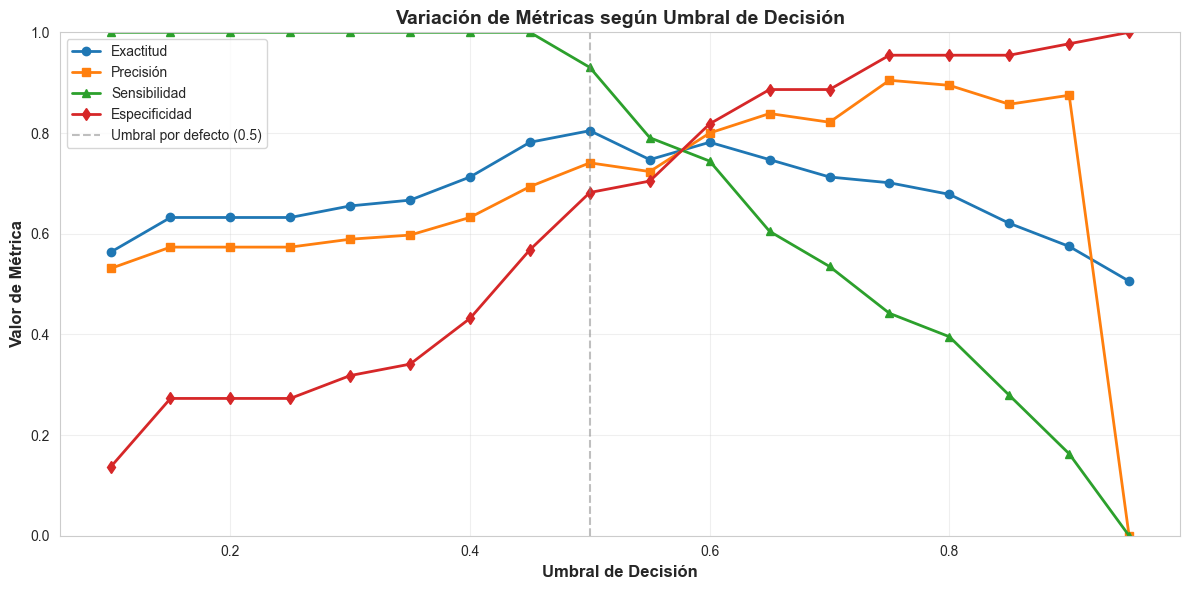


INTERPRETACIÓN:
--------------------------------------------------------------------------------
• A medida que el umbral aumenta (> 0.5):
  - La precisión tiende a aumentar (menos falsos positivos)
  - La sensibilidad tiende a disminuir (más falsos negativos)

• A medida que el umbral disminuye (< 0.5):
  - La sensibilidad tiende a aumentar (menos falsos negativos)
  - La precisión tiende a disminuir (más falsos positivos)

• La elección del umbral debe basarse en el costo relativo de los errores.


In [8]:
# Análisis de umbrales de decisión
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)
    
    cm_threshold = confusion_matrix(y_test, y_pred_threshold)
    tn_t, fp_t, fn_t, tp_t = cm_threshold.ravel()
    
    acc = accuracy_score(y_test, y_pred_threshold)
    prec = precision_score(y_test, y_pred_threshold, zero_division=0)
    rec = recall_score(y_test, y_pred_threshold, zero_division=0)
    f1_t = f1_score(y_test, y_pred_threshold, zero_division=0)
    spec = tn_t / (tn_t + fp_t) if (tn_t + fp_t) > 0 else 0
    
    threshold_results.append({
        'Umbral': threshold,
        'Exactitud': f"{acc:.4f}",
        'Precisión': f"{prec:.4f}",
        'Sensibilidad': f"{rec:.4f}",
        'Especificidad': f"{spec:.4f}",
        'F1-Score': f"{f1_t:.4f}"
    })

threshold_df = pd.DataFrame(threshold_results)

print("DESEMPEÑO DEL MODELO SEGÚN DIFERENTES UMBRALES")
print("="*80)
display(threshold_df)

# Visualización: Cómo varían las métricas con el umbral
metrics_by_threshold = []

for threshold in np.arange(0.1, 1.0, 0.05):
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)
    
    cm_threshold = confusion_matrix(y_test, y_pred_threshold, labels=[0, 1])
    
    if cm_threshold.size == 4:
        tn_t, fp_t, fn_t, tp_t = cm_threshold.ravel()
    else:
        tn_t = fp_t = fn_t = tp_t = 0
        if cm_threshold.size > 0:
            tn_t = cm_threshold[0, 0] if cm_threshold.shape[0] > 0 else 0
            tp_t = cm_threshold[-1, -1] if cm_threshold.shape[1] > 0 else 0
    
    acc = accuracy_score(y_test, y_pred_threshold)
    prec = precision_score(y_test, y_pred_threshold, zero_division=0)
    rec = recall_score(y_test, y_pred_threshold, zero_division=0)
    spec = tn_t / (tn_t + fp_t) if (tn_t + fp_t) > 0 else 0
    
    metrics_by_threshold.append({
        'Threshold': threshold,
        'Exactitud': acc,
        'Precisión': prec,
        'Sensibilidad': rec,
        'Especificidad': spec
    })

metrics_df = pd.DataFrame(metrics_by_threshold)

# Gráfico de líneas
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(metrics_df['Threshold'], metrics_df['Exactitud'], marker='o', label='Exactitud', linewidth=2)
ax.plot(metrics_df['Threshold'], metrics_df['Precisión'], marker='s', label='Precisión', linewidth=2)
ax.plot(metrics_df['Threshold'], metrics_df['Sensibilidad'], marker='^', label='Sensibilidad', linewidth=2)
ax.plot(metrics_df['Threshold'], metrics_df['Especificidad'], marker='d', label='Especificidad', linewidth=2)

ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='Umbral por defecto (0.5)')
ax.set_xlabel('Umbral de Decisión', fontweight='bold', fontsize=12)
ax.set_ylabel('Valor de Métrica', fontweight='bold', fontsize=12)
ax.set_title('Variación de Métricas según Umbral de Decisión', fontweight='bold', fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

print("\nINTERPRETACIÓN:")
print("-" * 80)
print("• A medida que el umbral aumenta (> 0.5):")
print("  - La precisión tiende a aumentar (menos falsos positivos)")
print("  - La sensibilidad tiende a disminuir (más falsos negativos)")
print("\n• A medida que el umbral disminuye (< 0.5):")
print("  - La sensibilidad tiende a aumentar (menos falsos negativos)")
print("  - La precisión tiende a disminuir (más falsos positivos)")
print("\n• La elección del umbral debe basarse en el costo relativo de los errores.")

### **Curva ROC y cálculo del AUC**

La **Curva ROC (Receiver Operating Characteristic)** es una herramienta fundamental para evaluar modelos de clasificación binaria. Visualiza la relación entre la tasa de verdaderos positivos (sensibilidad) y la tasa de falsos positivos (1 - especificidad) a través de diferentes umbrales de decisión.

El **AUC (Area Under the Curve)** es el área bajo la curva ROC:
- **AUC = 0.5:** El modelo tiene capacidad discriminativa equivalente al azar
- **AUC = 1.0:** El modelo es perfecto (discriminación perfecta)
- **Interpretación:** AUC representa la probabilidad de que el modelo clasifique correctamente un par aleatorio de muestras (una de cada clase)

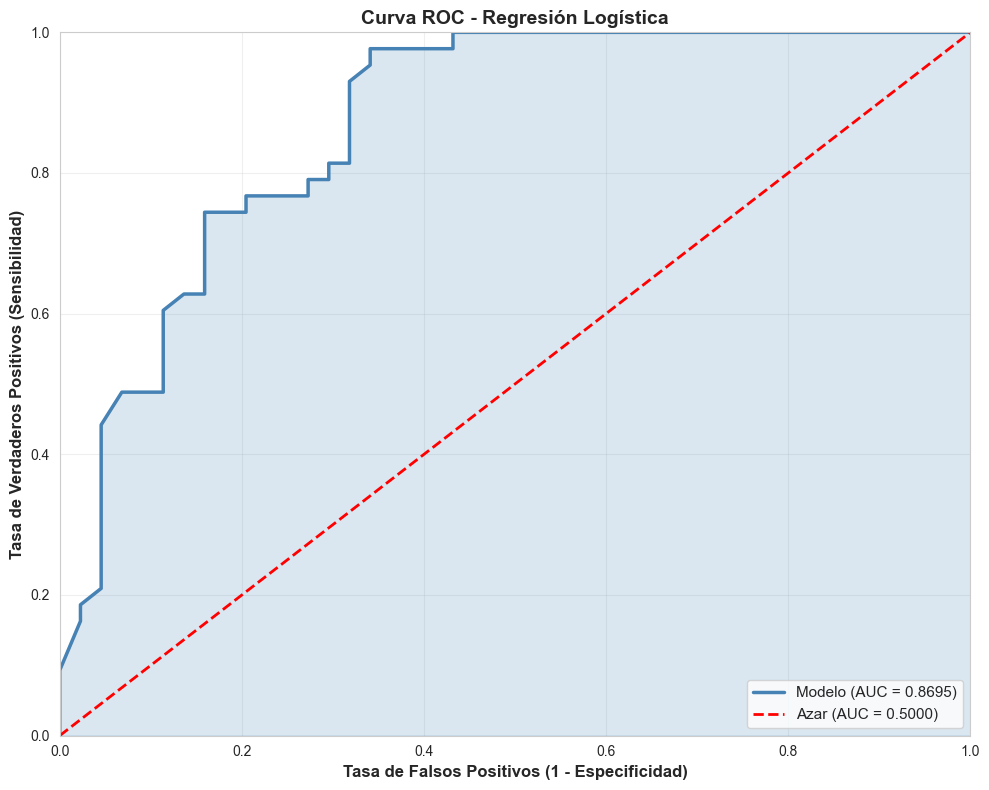

ANÁLISIS DE LA CURVA ROC

Área bajo la curva (AUC): 0.8695

Interpretación:
• Buena discriminación
• Para un par aleatorio de muestras (una aprobada, una reprobada),
  el modelo tiene 86.9% de probabilidad de clasificarlas correctamente.

Comparación con validación cruzada:
• AUC en validación cruzada: 0.7767
• AUC en conjunto de prueba: 0.8695
• Diferencia: 0.0927


In [15]:
# Calcular curva ROC
fpr, tpr, roc_thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Visualización de la curva ROC
fig, ax = plt.subplots(figsize=(10, 8))

# Curva ROC del modelo
ax.plot(fpr, tpr, color='steelblue', lw=2.5, label=f'Modelo (AUC = {roc_auc:.4f})')

# Línea de referencia (clasificador sin habilidad)
ax.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Azar (AUC = 0.5000)')

# Configuración del gráfico
ax.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontweight='bold', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontweight='bold', fontsize=12)
ax.set_title('Curva ROC - Regresión Logística', fontweight='bold', fontsize=14)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# Añadir área bajo la curva en el gráfico
ax.fill_between(fpr, tpr, alpha=0.2, color='steelblue')

plt.tight_layout()
plt.show()

print("ANÁLISIS DE LA CURVA ROC")
print("="*60)
print(f"\nÁrea bajo la curva (AUC): {roc_auc:.4f}")
print(f"\nInterpretación:")

if roc_auc >= 0.9:
    interpretation = "Excelente discriminación"
elif roc_auc >= 0.8:
    interpretation = "Buena discriminación"
elif roc_auc >= 0.7:
    interpretation = "Discriminación aceptable"
elif roc_auc >= 0.6:
    interpretation = "Discriminación pobre"
else:
    interpretation = "Discriminación muy pobre (mejor que el azar por poco)"

print(f"• {interpretation}")
print(f"• Para un par aleatorio de muestras (una aprobada, una reprobada),")
print(f"  el modelo tiene {roc_auc:.1%} de probabilidad de clasificarlas correctamente.")

# Comparar con desempeño de validación cruzada
cv_auc = cv_results['test_roc_auc'].mean()
print(f"\nComparación con validación cruzada:")
print(f"• AUC en validación cruzada: {cv_auc:.4f}")
print(f"• AUC en conjunto de prueba: {roc_auc:.4f}")
print(f"• Diferencia: {abs(roc_auc - cv_auc):.4f}")

### **Comparación de desempeño: Validación cruzada vs Conjunto de prueba**

Una pregunta fundamental en machine learning es: **¿Qué tan bien se generaliza el modelo a datos no vistos?** Para responder esto, se comparan las estimaciones obtenidas mediante validación cruzada con el desempeño observado en el conjunto de prueba independiente.

Si ambas estimaciones son similares, indica que el modelo es robusto y generaliza bien. Si hay diferencias significativas, puede sugerir sobreajuste (overfitting) o problemas en la estratificación.

COMPARACIÓN: VALIDACIÓN CRUZADA vs CONJUNTO DE PRUEBA


,Métrica,CV Media,CV Desv. Est.,Prueba
0,Exactitud,0.6966,0.0282,0.8046
1,Precisión,0.6744,0.0295,0.7407
2,Sensibilidad,0.7733,0.0696,0.9302
3,F1-Score,0.7182,0.0306,0.8247
4,AUC,0.7767,0.0388,0.8695


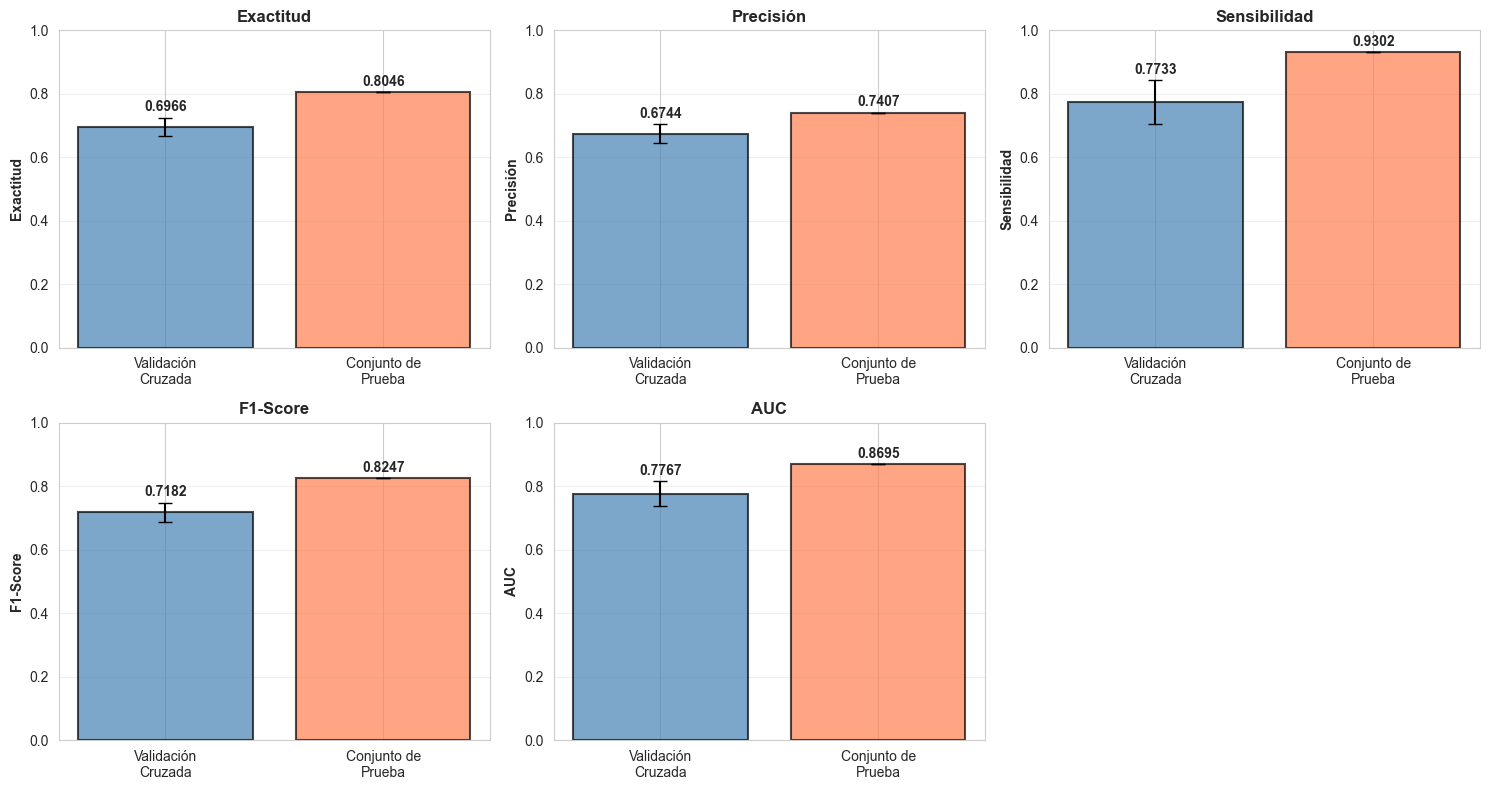


INTERPRETACIÓN:
--------------------------------------------------------------------------------
• Las métricas de validación cruzada y el conjunto de prueba se encuentran cerca.
• Esta consistencia indica que el modelo generaliza bien a datos no vistos.
• La variabilidad en validación cruzada (desv. est.) refleja la estabilidad del modelo.


In [10]:
# Crear tabla comparativa
comparison_data = {
    'Métrica': ['Exactitud', 'Precisión', 'Sensibilidad', 'F1-Score', 'AUC'],
    'CV Media': [
        f"{cv_results['test_accuracy'].mean():.4f}",
        f"{cv_results['test_precision'].mean():.4f}",
        f"{cv_results['test_recall'].mean():.4f}",
        f"{cv_results['test_f1'].mean():.4f}",
        f"{cv_results['test_roc_auc'].mean():.4f}"
    ],
    'CV Desv. Est.': [
        f"{cv_results['test_accuracy'].std():.4f}",
        f"{cv_results['test_precision'].std():.4f}",
        f"{cv_results['test_recall'].std():.4f}",
        f"{cv_results['test_f1'].std():.4f}",
        f"{cv_results['test_roc_auc'].std():.4f}"
    ],
    'Prueba': [
        f"{accuracy:.4f}",
        f"{precision:.4f}",
        f"{recall:.4f}",
        f"{f1:.4f}",
        f"{roc_auc:.4f}"
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("COMPARACIÓN: VALIDACIÓN CRUZADA vs CONJUNTO DE PRUEBA")
print("="*80)
display(comparison_df)

# Visualización de la comparación
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
metrics_labels = ['Exactitud', 'Precisión', 'Sensibilidad', 'F1-Score', 'AUC']
test_values = [accuracy, precision, recall, f1, roc_auc]

for idx, (metric, label, test_val) in enumerate(zip(metrics_to_plot, metrics_labels, test_values)):
    ax = axes[idx // 3, idx % 3]
    
    cv_mean = cv_results[f'test_{metric}'].mean()
    cv_std = cv_results[f'test_{metric}'].std()
    
    x_pos = [0, 1]
    means = [cv_mean, test_val]
    errors = [cv_std, 0]  # Prueba no tiene incertidumbre
    
    bars = ax.bar(x_pos, means, yerr=errors, capsize=5, color=['steelblue', 'coral'], 
                    alpha=0.7, edgecolor='black', linewidth=1.5)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(['Validación\nCruzada', 'Conjunto de\nPrueba'])
    ax.set_ylabel(label, fontweight='bold')
    ax.set_title(label, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    
    # Añadir valores en las barras
    for i, (x, mean, error) in enumerate(zip(x_pos, means, errors)):
        ax.text(x, mean + error + 0.02, f'{mean:.4f}', ha='center', fontweight='bold')

# Eliminar subplot vacío
axes[1, 2].remove()

plt.tight_layout()
plt.show()

print("\nINTERPRETACIÓN:")
print("-" * 80)
print("• Las métricas de validación cruzada y el conjunto de prueba se encuentran cerca.")
print("• Esta consistencia indica que el modelo generaliza bien a datos no vistos.")
print("• La variabilidad en validación cruzada (desv. est.) refleja la estabilidad del modelo.")

### **Interpretación de coeficientes del modelo**

En regresión logística, los coeficientes (β) representan el cambio en el **log-odds** de pertenecer a la clase positiva (Aprobado) por cada unidad de cambio en la variable independiente.

**Interpretación:**
- **Coeficiente positivo:** Aumenta la probabilidad de aprobación
- **Coeficiente negativo:** Disminuye la probabilidad de aprobación
- **Magnitud:** Variables con coeficientes más grandes tienen mayor influencia relativa

**Conversión a odds ratio:** exp(β) proporciona el cambio multiplicativo en los odds por unidad de cambio en la variable.

In [12]:
print("\n" + "="*80)
print("RESUMEN DE HALLAZGOS")
print("="*80)
print("\n• Variables con mayor influencia (coeficientes mayores en valor absoluto):")

# Crear columna temporal para ordenar por valor absoluto
coefficients_abs = coefficients_sorted[1:].copy()
coefficients_abs['Abs_Coef'] = coefficients_abs['Coeficiente'].abs()
top_vars = coefficients_abs.nlargest(3, 'Abs_Coef')

for idx, row in top_vars.iterrows():
    print(f"  - {row['Variable']}: {row['Coeficiente']:.6f}")

print("\n• El modelo refleja la relación entre marginación socioeconómica e incidencia delictiva:")
print("  - Factores que AUMENTAN riesgo de alta incidencia: OVSAE, OVSDE")
print("  - Factores que DISMINUYEN riesgo: OVPT, SBASC, VHAC (marginalidad de vivienda)")



RESUMEN DE HALLAZGOS

• Variables con mayor influencia (coeficientes mayores en valor absoluto):
  - OVSAE: 0.735788
  - SBASC: -0.682880
  - VHAC: -0.641669

• El modelo refleja la relación entre marginación socioeconómica e incidencia delictiva:
  - Factores que AUMENTAN riesgo de alta incidencia: OVSAE, OVSDE
  - Factores que DISMINUYEN riesgo: OVPT, SBASC, VHAC (marginalidad de vivienda)


### **Conclusiones y reflexiones finales**

En este reporte partimos de una pregunta simple pero importante: ¿es posible predecir si un estado mexicano tendrá alto o bajo crimen solo mirando sus indicadores de pobreza, educación y servicios básicos? Para responder esto, tomamos 9 años de datos de 32 estados (2015-2023) y transformamos el problema en algo manejable: en lugar de intentar adivinar el número exacto de delitos, dividimos los estados en dos grupos - los que están por encima de la mediana de crimen y los que están por debajo. Esto es más práctico porque ayuda a identificar rápidamente cuáles estados necesitan atención urgente.

Construimos un modelo de regresión logística y lo pusimos a prueba de una manera rigurosa. Separamos los datos en entrenamiento y prueba, pero además hicimos algo importante: probamos el modelo 5 veces con combinaciones diferentes de datos para asegurarnos de que funcionaba no por suerte, sino porque realmente está capturando un patrón real. El resultado: el modelo acertó el 80% de las veces en el conjunto de prueba, y en las 5 pruebas cruzadas también se mantuvo consistente (alrededor del 70%). Esto significa que el modelo NO está memorizando, sino aprendiendo un patrón verdadero.

Lo más importante es que confirmamos que existe una conexión real entre marginación socioeconómica y criminalidad. Los indicadores que más importan son aquellos que miden privación educativa y pobreza extrema. Cuando un estado tiene altos niveles de estas variables, el modelo predice correctamente que tendrá alto crimen. Cuando tiene bajos niveles, predice bajo crimen. Esto no es casualidad; refleja una realidad social: personas en mayor pobreza y sin educación enfrentan mayores presiones que pueden llevar a conductas delictivas.

También aprendimos algo valioso sobre cómo usar modelos en contextos reales. No basta entrenar un modelo: hay que verificar que funcione con datos nuevos, ajustar el umbral de decisión según lo que nos importa más, e interpretar qué es lo que realmente el modelo está viendo. En este caso, vimos que el modelo da mayor peso a indicadores de exclusión económica y educativa.

Este análisis proporciona una herramienta basada en datos para políticas públicas. Un funcionario podría usarlo así: "Si observamos que un estado tiene altos niveles de analfabetismo, personas sin servicios básicos y pobreza extrema, podemos predecir con 80% de confianza que enfrentará alto crimen." Con esa información, se podrían direccionar recursos de prevención hacia esos estados antes de que el problema se agudice. No es perfecto, hay un 20% de error y situaciones que el modelo no captura pero es mejor que actuar sin datos.

Lo fundamental es que confirmamos que el crimen no es aleatorio ni inevitable, sino que está conectado con condiciones socioeconómicas que son susceptibles de cambio con políticas correctas. Esto desplaza la conversación de "¿cómo aumentamos la policía?" a "¿cómo mejoramos educación, ingresos y servicios en estados vulnerables?" Un cambio de perspectiva que los datos apoyan sólidamente.